In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import gc
from src.config.path import PROCESS_PATH, RAW_PATH

In [2]:
df = pd.read_parquet(PROCESS_PATH / "flight.parquet")
df

,flight,payload,route,altitude_preset,date,time_day,duration_s,total_distance_m,wind_speed_mean,wind_speed_std,...,velocity_mag_max,acceleration_mag_mean,acceleration_mag_std,battery_voltage_mean,battery_voltage_min,max_height_agl,final_height_agl,energy_consumed_Wh,battery_needed_mAh,landing_offset_flag
0,1,0.0,R5,25,2019-04-07,10:13,200.70,549.065984,3.898058,1.952675,...,6.261616,9.842870,0.466372,22.070134,21.228519,26.257755,-0.994409,21.769975,1000.743935,False
1,2,0.0,R5,50,2019-04-07,10:23,271.20,666.615556,3.522941,2.159456,...,7.676739,9.881874,0.628406,21.527547,20.125463,52.637988,0.589477,25.366627,1205.255874,False
2,3,0.0,R5,25,2019-04-07,10:33,180.10,577.009957,4.581182,3.335733,...,7.213987,9.902090,0.545290,22.330305,19.943916,24.660462,0.106140,17.094392,789.073853,False
3,4,0.0,R5,25,2019-04-07,10:48,171.00,562.802357,4.596319,3.438072,...,9.425537,9.900368,0.559073,21.950616,20.365856,25.580572,0.416669,14.690038,687.813976,False
4,5,0.0,R2,25,2019-04-07,11:05,217.00,470.978276,3.333910,2.247522,...,4.900079,9.817243,0.341981,21.519937,18.923494,24.323036,-0.924901,19.019928,920.070980,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,275,500.0,R1,25,2019-10-24,9:05,149.40,518.231162,4.139878,3.885389,...,8.788151,9.850903,0.420902,22.056616,20.332052,21.959932,-3.264891,16.295811,760.480643,False
205,276,500.0,R1,25,2019-10-24,9:32,147.90,517.758034,4.392581,4.332293,...,10.553163,9.862172,0.471081,21.492353,19.788662,22.542598,1.293232,15.392088,738.620356,False
206,277,500.0,R1,25,2019-10-24,9:45,134.81,517.677109,5.524651,4.029744,...,10.579715,9.847796,0.529103,21.908016,19.352947,24.289124,-0.286362,15.531389,741.451254,False
207,278,500.0,R7,25-50-100-25,2019-10-24,10:00,186.39,545.413261,4.686967,3.826570,...,10.376503,9.829065,0.456918,22.394109,20.407175,95.041887,-0.457578,18.922540,887.198699,False


In [ ]:
sns.set_theme(style="whitegrid", font_scale=1.05)
TARGET = "energy_consumed_Wh"
 
def pearson(x, y):
    """Return (r, p) ignoring NaNs."""
    mask = x.notna() & y.notna()
    r, p = stats.pearsonr(x[mask], y[mask])
    return r, p
 


[total_distance_m] r=0.718, p=2.24e-34
mean    560.989341
std     160.333597
min       0.000000
max     979.551813
Name: total_distance_m, dtype: float64


Text(0, 0.5, 'Energy consumed (Wh)')

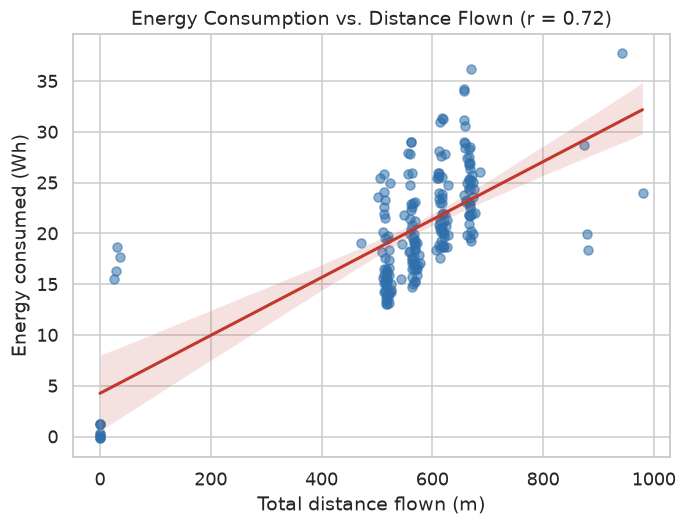

In [9]:
r, p = pearson(df["total_distance_m"], df[TARGET])
print(f"\n[total_distance_m] r={r:.3f}, p={p:.2e}")
print(df["total_distance_m"].describe()[["mean", "std", "min", "max"]])
 
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(
    data=df, x="total_distance_m", y=TARGET,
    scatter_kws=dict(alpha=0.55, s=35, color="#2f6fab"),
    line_kws=dict(color="#c0392b", linewidth=2),
    ax=ax,
)
ax.set_title(f"Energy Consumption vs. Distance Flown (r = {r:.2f})")
ax.set_xlabel("Total distance flown (m)")
ax.set_ylabel("Energy consumed (Wh)")


[max_height_agl] r=0.654, p=6.23e-27
mean     57.937022
std      31.445999
min       0.000000
max     107.730422
Name: max_height_agl, dtype: float64


Text(0, 0.5, 'Energy consumed (Wh)')

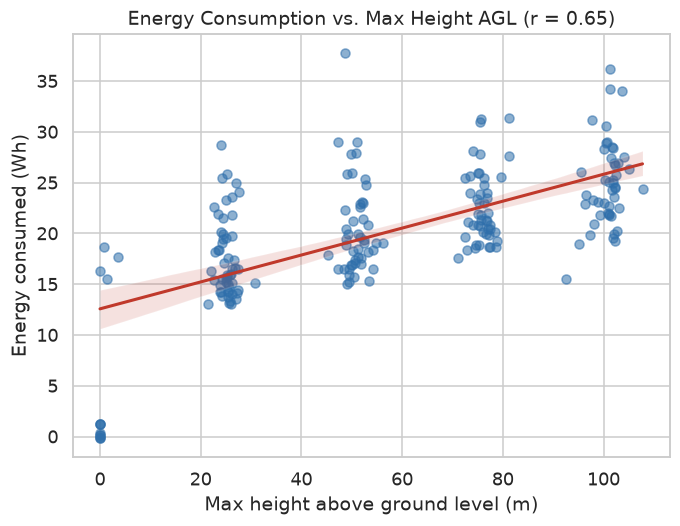

In [10]:
r, p = pearson(df["max_height_agl"], df[TARGET])
print(f"\n[max_height_agl] r={r:.3f}, p={p:.2e}")
print(df["max_height_agl"].describe()[["mean", "std", "min", "max"]])
 
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(
    data=df, x="max_height_agl", y=TARGET,
    scatter_kws=dict(alpha=0.55, s=35, color="#2f6fab"),
    line_kws=dict(color="#c0392b", linewidth=2),
    ax=ax,
)
ax.set_title(f"Energy Consumption vs. Max Height AGL (r = {r:.2f})")
ax.set_xlabel("Max height above ground level (m)")
ax.set_ylabel("Energy consumed (Wh)")


[payload] value counts:
payload
0.0      80
250.0    62
500.0    66
750.0     1
Name: count, dtype: int64
              mean       std  count
payload                            
0.0      16.941347  6.887036     80
250.0    21.434630  4.803570     62
500.0    23.077631  5.197821     66
750.0    25.841372       NaN      1


Text(0, 0.5, 'Energy consumed (Wh)')

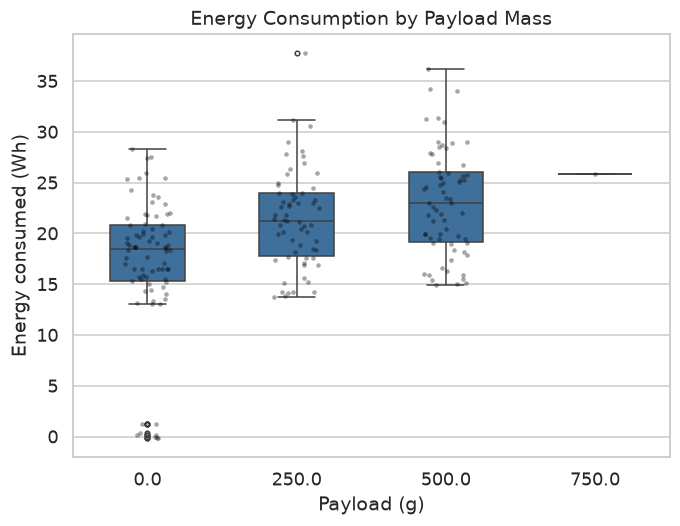

In [11]:
print("\n[payload] value counts:")
print(df["payload"].value_counts().sort_index())
print(df.groupby("payload")[TARGET].agg(["mean", "std", "count"]))
 
fig, ax = plt.subplots(figsize=(7, 5))
order = sorted(df["payload"].unique())
sns.boxplot(
    data=df, x="payload", y=TARGET, order=order,
    color="#2f6fab", width=0.5, fliersize=3, ax=ax
)
sns.stripplot(
    data=df, x="payload", y=TARGET, order=order,
    color="black", alpha=0.35, size=3, jitter=0.15, ax=ax
)
ax.set_title("Energy Consumption by Payload Mass")
ax.set_xlabel("Payload (g)")
ax.set_ylabel("Energy consumed (Wh)")


[wind_speed_mean] r=0.390, p=5.36e-09
mean    4.309472
std     1.240479
min     0.086990
max     6.670192
Name: wind_speed_mean, dtype: float64


Text(0, 0.5, 'Energy consumed (Wh)')

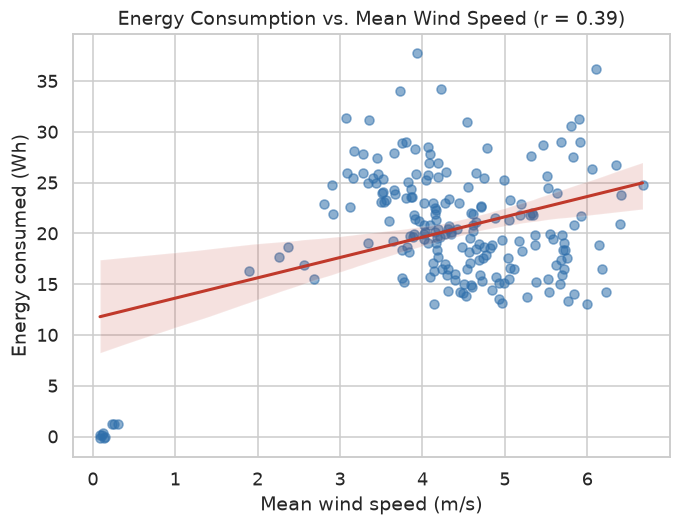

In [12]:
r, p = pearson(df["wind_speed_mean"], df[TARGET])
print(f"\n[wind_speed_mean] r={r:.3f}, p={p:.2e}")
print(df["wind_speed_mean"].describe()[["mean", "std", "min", "max"]])
 
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(
    data=df, x="wind_speed_mean", y=TARGET,
    scatter_kws=dict(alpha=0.55, s=35, color="#2f6fab"),
    line_kws=dict(color="#c0392b", linewidth=2),
    ax=ax,
)
ax.set_title(f"Energy Consumption vs. Mean Wind Speed (r = {r:.2f})")
ax.set_xlabel("Mean wind speed (m/s)")
ax.set_ylabel("Energy consumed (Wh)")


[acceleration_mag_std] r=0.342, p=4.14e-07
mean    0.431917
std     0.120044
min     0.001204
max     0.689650
Name: acceleration_mag_std, dtype: float64


Text(0, 0.5, 'Energy consumed (Wh)')

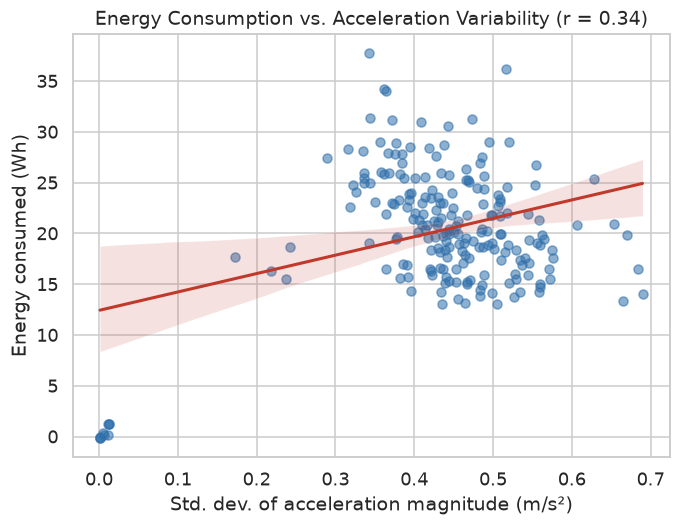

In [13]:
r, p = pearson(df["acceleration_mag_std"], df[TARGET])
print(f"\n[acceleration_mag_std] r={r:.3f}, p={p:.2e}")
print(df["acceleration_mag_std"].describe()[["mean", "std", "min", "max"]])
 
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(
    data=df, x="acceleration_mag_std", y=TARGET,
    scatter_kws=dict(alpha=0.55, s=35, color="#2f6fab"),
    line_kws=dict(color="#c0392b", linewidth=2),
    ax=ax,
)
ax.set_title(f"Energy Consumption vs. Acceleration Variability (r = {r:.2f})")
ax.set_xlabel("Std. dev. of acceleration magnitude (m/s\u00b2)")
ax.set_ylabel("Energy consumed (Wh)")


[velocity_mag_mean] r=0.253, p=2.24e-04
mean    2.991116
std     0.914835
min     0.000000
max     4.846205
Name: velocity_mag_mean, dtype: float64


Text(0, 0.5, 'Energy consumed (Wh)')

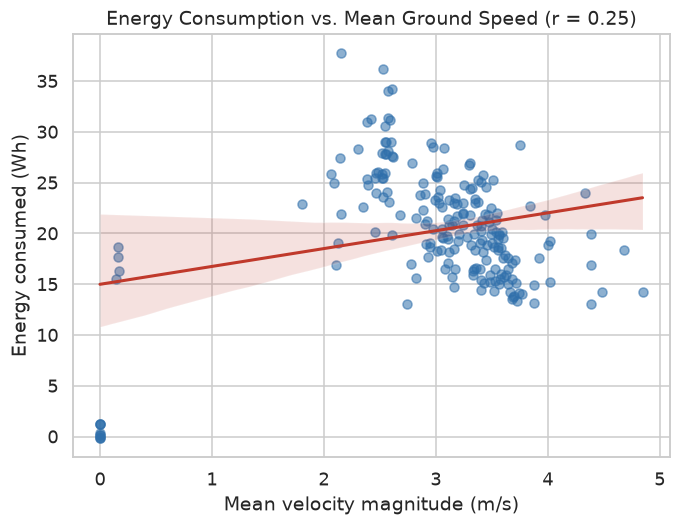

In [14]:
r, p = pearson(df["velocity_mag_mean"], df[TARGET])
print(f"\n[velocity_mag_mean] r={r:.3f}, p={p:.2e}")
print(df["velocity_mag_mean"].describe()[["mean", "std", "min", "max"]])
 
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(
    data=df, x="velocity_mag_mean", y=TARGET,
    scatter_kws=dict(alpha=0.55, s=35, color="#2f6fab"),
    line_kws=dict(color="#c0392b", linewidth=2),
    ax=ax,
)
ax.set_title(f"Energy Consumption vs. Mean Ground Speed (r = {r:.2f})")
ax.set_xlabel("Mean velocity magnitude (m/s)")
ax.set_ylabel("Energy consumed (Wh)")


[acceleration_mag_mean] r with energy=-0.257, r with duration_s=-0.408
mean    9.845213
std     0.025930
min     9.796791
max     9.918788
Name: acceleration_mag_mean, dtype: float64


Text(0, 0.5, 'Energy consumed (Wh)')

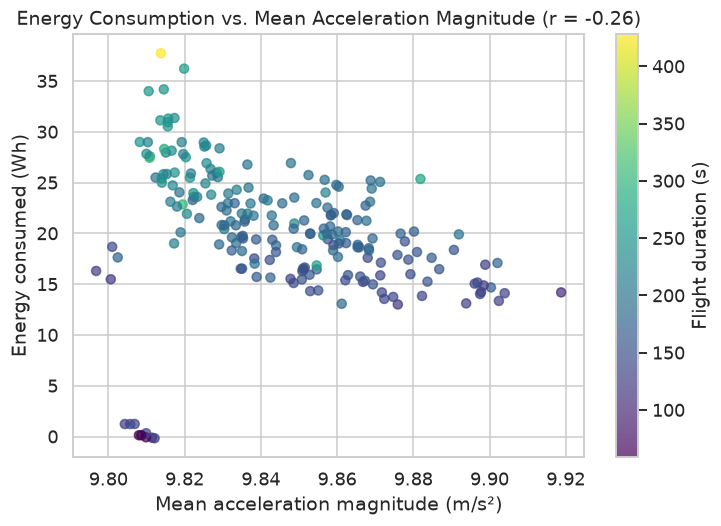

In [15]:
r_energy, _ = pearson(df["acceleration_mag_mean"], df[TARGET])
r_duration, _ = pearson(df["acceleration_mag_mean"], df["duration_s"])
print(f"\n[acceleration_mag_mean] r with energy={r_energy:.3f}, "
      f"r with duration_s={r_duration:.3f}")
print(df["acceleration_mag_mean"].describe()[["mean", "std", "min", "max"]])
 
fig, ax = plt.subplots(figsize=(7.5, 5))
sc = ax.scatter(
    df["acceleration_mag_mean"], df[TARGET],
    c=df["duration_s"], cmap="viridis", alpha=0.7, s=35
)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Flight duration (s)")
ax.set_title(f"Energy Consumption vs. Mean Acceleration Magnitude (r = {r_energy:.2f})")
ax.set_xlabel("Mean acceleration magnitude (m/s\u00b2)")
ax.set_ylabel("Energy consumed (Wh)")